# Consecutive Winning Streak → Forward Returns Backtest

**Objective:** Test whether N consecutive up-days in an index (SPX, NDX, etc.) carry any predictive signal for forward returns at various horizons.

**Approach:**
1. Pull daily close data from Yahoo Finance (swap in Bloomberg if preferred)
2. Identify all streaks of N+ consecutive positive daily returns
3. Compute forward returns at 1d, 5d, 20d, 60d, 125d, 250d after each streak ends
4. Compare streak-conditional returns against unconditional baselines
5. Visualize distributions and statistical significance

In [1]:
# ── Dependencies ──────────────────────────────────────────────
# pip install yfinance pandas numpy matplotlib seaborn scipy

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

print('Setup complete.')

c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Setup complete.


## 1. Configuration

Change these parameters to explore different assets and streak lengths.

In [2]:
# ── Config ─────────────────────────────────────────────────────

# Tickers to analyze — add/remove as needed
# Yahoo Finance tickers: ^GSPC (S&P 500), ^IXIC (Nasdaq Comp), ^DJI (Dow),
# ^RUT (Russell 2000), CL=F (WTI crude), GC=F (Gold)
TICKERS = {
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
}

# Minimum streak lengths to test (consecutive up-days)
STREAK_THRESHOLDS = [5, 7, 9, 12]

# Forward return horizons (trading days)
FWD_HORIZONS = {
    '1d': 1,
    '1w': 5,
    '1m': 20,
    '3m': 60,
    '6m': 125,
    '12m': 250,
}

# Data start date — go as far back as Yahoo allows
START_DATE = '1970-01-01'
END_DATE = datetime.today().strftime('%Y-%m-%d')

print(f'Will analyze: {list(TICKERS.values())}')
print(f'Streak thresholds: {STREAK_THRESHOLDS}')
print(f'Forward horizons: {list(FWD_HORIZONS.keys())}')
print(f'Date range: {START_DATE} → {END_DATE}')

Will analyze: ['S&P 500', 'Nasdaq Composite']
Streak thresholds: [5, 7, 9, 12]
Forward horizons: ['1d', '1w', '1m', '3m', '6m', '12m']
Date range: 1970-01-01 → 2026-04-22


## 2. Data Pull & Preprocessing

In [3]:
# ── Pull data ─────────────────────────────────────────────────

def pull_data(tickers: dict, start: str, end: str) -> dict:
    """Download daily close prices for each ticker."""
    data = {}
    for ticker, name in tickers.items():
        print(f'  Downloading {name} ({ticker})...')
        df = yf.download(ticker, start=start, end=end, progress=False)
        if df.empty:
            print(f'    ⚠ No data returned for {ticker}, skipping.')
            continue
        # Flatten MultiIndex columns if present (yfinance quirk)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df[['Close']].copy()
        df.columns = ['close']
        df.index = pd.to_datetime(df.index)
        df = df.sort_index()
        df['daily_ret'] = df['close'].pct_change()
        data[name] = df.dropna()
        print(f'    ✓ {len(data[name]):,} trading days ({data[name].index[0].date()} → {data[name].index[-1].date()})')
    return data

price_data = pull_data(TICKERS, START_DATE, END_DATE)

    ✓ 14,195 trading days (1970-01-05 → 2026-04-21)
    ✓ 13,917 trading days (1971-02-08 → 2026-04-21)


## 3. Streak Detection

For each day, compute the running count of consecutive up-days ending on that date. A "streak event" is defined as the **last day** of a streak that reaches at least N days — i.e., the day the streak breaks (or the series ends). This avoids double-counting overlapping streaks.

In [4]:
def compute_streaks(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add a 'streak' column: running count of consecutive up-days.
    Resets to 0 on any non-positive return day.
    """
    up = (df['daily_ret'] > 0).astype(int)
    # Group consecutive runs
    groups = (up != up.shift()).cumsum()
    df['streak'] = up.groupby(groups).cumsum()
    return df


def find_streak_events(df: pd.DataFrame, min_streak: int) -> pd.DataFrame:
    """
    Identify the LAST day of each streak >= min_streak.
    A streak "ends" when the next day is not an up-day (or is the last row).
    This gives non-overlapping events.
    """
    # A streak ends when the next row's streak is lower (or it's the last row)
    streak_end = df['streak'] >= min_streak
    next_continues = df['streak'].shift(-1) > df['streak']
    # Keep only the terminal day of each streak run
    events = df[streak_end & ~next_continues].copy()
    events = events.rename(columns={'streak': 'streak_length'})
    return events


# Apply to all assets
for name, df in price_data.items():
    price_data[name] = compute_streaks(df)

# Quick sanity check
sample = list(price_data.values())[0]
max_streak = sample['streak'].max()
print(f'Longest streak in {list(price_data.keys())[0]}: {max_streak} consecutive up-days')
print(f'\nStreak distribution (top 10):')
print(sample[sample['streak'] > 0]['streak'].value_counts().sort_index().tail(10))

Longest streak in S&P 500: 14 consecutive up-days

Streak distribution (top 10):
streak
5     259
6     139
7      69
8      34
9      16
10      8
11      6
12      4
13      1
14      1
Name: count, dtype: int64


## 4. Forward Return Calculation

In [5]:
def compute_forward_returns(df: pd.DataFrame, horizons: dict) -> pd.DataFrame:
    """
    For every row, compute the forward return at each horizon.
    Forward return = (close[t+h] / close[t]) - 1
    """
    for label, days in horizons.items():
        df[f'fwd_{label}'] = df['close'].shift(-days) / df['close'] - 1
    return df


for name, df in price_data.items():
    price_data[name] = compute_forward_returns(df, FWD_HORIZONS)

print('Forward returns computed.')
print(f'Columns: {list(price_data[list(price_data.keys())[0]].columns)}')

Forward returns computed.
Columns: ['close', 'daily_ret', 'streak', 'fwd_1d', 'fwd_1w', 'fwd_1m', 'fwd_3m', 'fwd_6m', 'fwd_12m']


## 5. Results Table: Conditional vs Unconditional Returns

The core question: after an N-day winning streak, are forward returns statistically different from the "any random day" baseline?

In [6]:
def build_results_table(price_data: dict, streak_thresholds: list, horizons: dict) -> pd.DataFrame:
    """
    For each asset × streak threshold × horizon, compute:
    - N events (number of streak occurrences)
    - Conditional mean/median forward return
    - Unconditional mean/median forward return
    - Win rate (% of events with positive forward return)
    - p-value from Welch's t-test (conditional vs unconditional)
    """
    rows = []
    fwd_cols = [f'fwd_{label}' for label in horizons.keys()]

    for name, df in price_data.items():
        for min_streak in streak_thresholds:
            events = find_streak_events(df, min_streak)
            n_events = len(events)

            for label in horizons.keys():
                col = f'fwd_{label}'
                cond = events[col].dropna()
                uncond = df[col].dropna()

                if len(cond) < 3:
                    continue

                # Welch's t-test: is the conditional mean different from unconditional?
                t_stat, p_val = stats.ttest_ind(cond, uncond, equal_var=False)

                rows.append({
                    'asset': name,
                    'min_streak': min_streak,
                    'horizon': label,
                    'n_events': n_events,
                    'cond_mean': cond.mean(),
                    'cond_median': cond.median(),
                    'uncond_mean': uncond.mean(),
                    'uncond_median': uncond.median(),
                    'win_rate': (cond > 0).mean(),
                    'uncond_win_rate': (uncond > 0).mean(),
                    'p_value': p_val,
                })

    return pd.DataFrame(rows)


results = build_results_table(price_data, STREAK_THRESHOLDS, FWD_HORIZONS)
print(f'Results table: {len(results)} rows')
results.head(10)

Results table: 48 rows


,asset,min_streak,horizon,n_events,cond_mean,cond_median,uncond_mean,uncond_median,win_rate,uncond_win_rate,p_value
0,S&P 500,5,1d,259,-0.005082,-0.003404,0.000363,0.000489,0.000000,0.529660,4.217128e-26
1,S&P 500,5,1w,259,-0.002404,0.000490,0.001804,0.002967,0.511628,0.564834,8.827112e-05
2,S&P 500,5,1m,259,0.002312,0.005592,0.007118,0.010730,0.587549,0.612698,2.552889e-02
3,S&P 500,5,3m,259,0.016130,0.019733,0.021461,0.026156,0.656250,0.666006,2.291725e-01
4,S&P 500,5,6m,259,0.045055,0.048091,0.046043,0.051122,0.712598,0.703554,8.687018e-01
5,S&P 500,5,12m,259,0.087444,0.092360,0.094205,0.110234,0.764000,0.762065,4.397014e-01
6,S&P 500,7,1d,69,-0.005343,-0.003801,0.000363,0.000489,0.000000,0.529660,1.007844e-09
7,S&P 500,7,1w,69,-0.001867,0.000243,0.001804,0.002967,0.507246,0.564834,6.896410e-02
8,S&P 500,7,1m,69,0.004798,0.007167,0.007118,0.010730,0.617647,0.612698,5.632485e-01
9,S&P 500,7,3m,69,0.028375,0.020624,0.021461,0.026156,0.735294,0.666006,3.601881e-01


In [7]:
# ── Pretty-print the summary table ────────────────────────────

def format_results(results: pd.DataFrame) -> None:
    """Print a clean summary for each asset × streak combo."""
    for asset in results['asset'].unique():
        print(f'\n{"=" * 80}')
        print(f'  {asset}')
        print(f'{"=" * 80}')

        for min_streak in results['min_streak'].unique():
            subset = results[(results['asset'] == asset) & (results['min_streak'] == min_streak)]
            if subset.empty:
                continue

            n = subset.iloc[0]['n_events']
            print(f'\n  Streak ≥ {min_streak} consecutive up-days  |  {n} events')
            print(f'  {"─" * 74}')
            print(f'  {"Horizon":>8s}  {"Cond Mean":>10s}  {"Uncond Mean":>11s}  '
                  f'{"Cond Med":>9s}  {"Win Rate":>9s}  {"Unc WR":>7s}  {"p-val":>7s}')
            print(f'  {"─" * 74}')

            for _, row in subset.iterrows():
                sig = '**' if row['p_value'] < 0.05 else '*' if row['p_value'] < 0.10 else ''
                print(f'  {row["horizon"]:>8s}  {row["cond_mean"]:>+9.2%}  '
                      f'{row["uncond_mean"]:>+10.2%}  {row["cond_median"]:>+8.2%}  '
                      f'{row["win_rate"]:>8.1%}  {row["uncond_win_rate"]:>6.1%}  '
                      f'{row["p_value"]:>6.3f} {sig}')

    print(f'\n  ** p < 0.05  |  * p < 0.10')


format_results(results)


  S&P 500

  Streak ≥ 5 consecutive up-days  |  259 events
  ──────────────────────────────────────────────────────────────────────────
   Horizon   Cond Mean  Uncond Mean   Cond Med   Win Rate   Unc WR    p-val
  ──────────────────────────────────────────────────────────────────────────
        1d     -0.51%      +0.04%    -0.34%      0.0%   53.0%   0.000 **
        1w     -0.24%      +0.18%    +0.05%     51.2%   56.5%   0.000 **
        1m     +0.23%      +0.71%    +0.56%     58.8%   61.3%   0.026 **
        3m     +1.61%      +2.15%    +1.97%     65.6%   66.6%   0.229 
        6m     +4.51%      +4.60%    +4.81%     71.3%   70.4%   0.869 
       12m     +8.74%      +9.42%    +9.24%     76.4%   76.2%   0.440 

  Streak ≥ 7 consecutive up-days  |  69 events
  ──────────────────────────────────────────────────────────────────────────
   Horizon   Cond Mean  Uncond Mean   Cond Med   Win Rate   Unc WR    p-val
  ──────────────────────────────────────────────────────────────────────────


## 6. Visualization: Forward Return Distributions

Compare the distribution of forward returns after streak events vs the unconditional distribution.

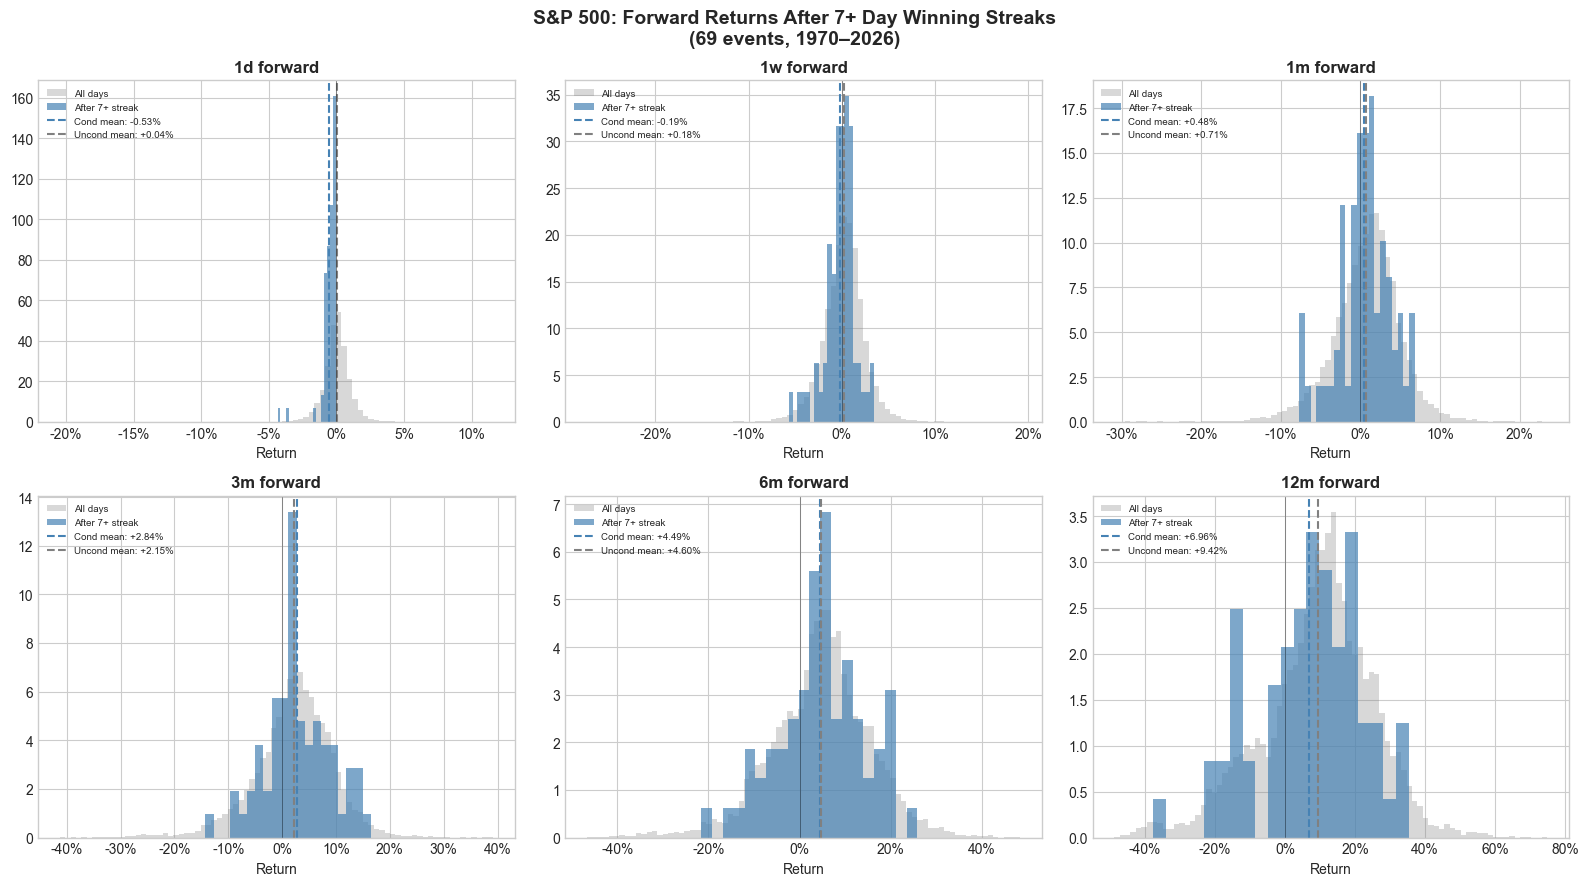

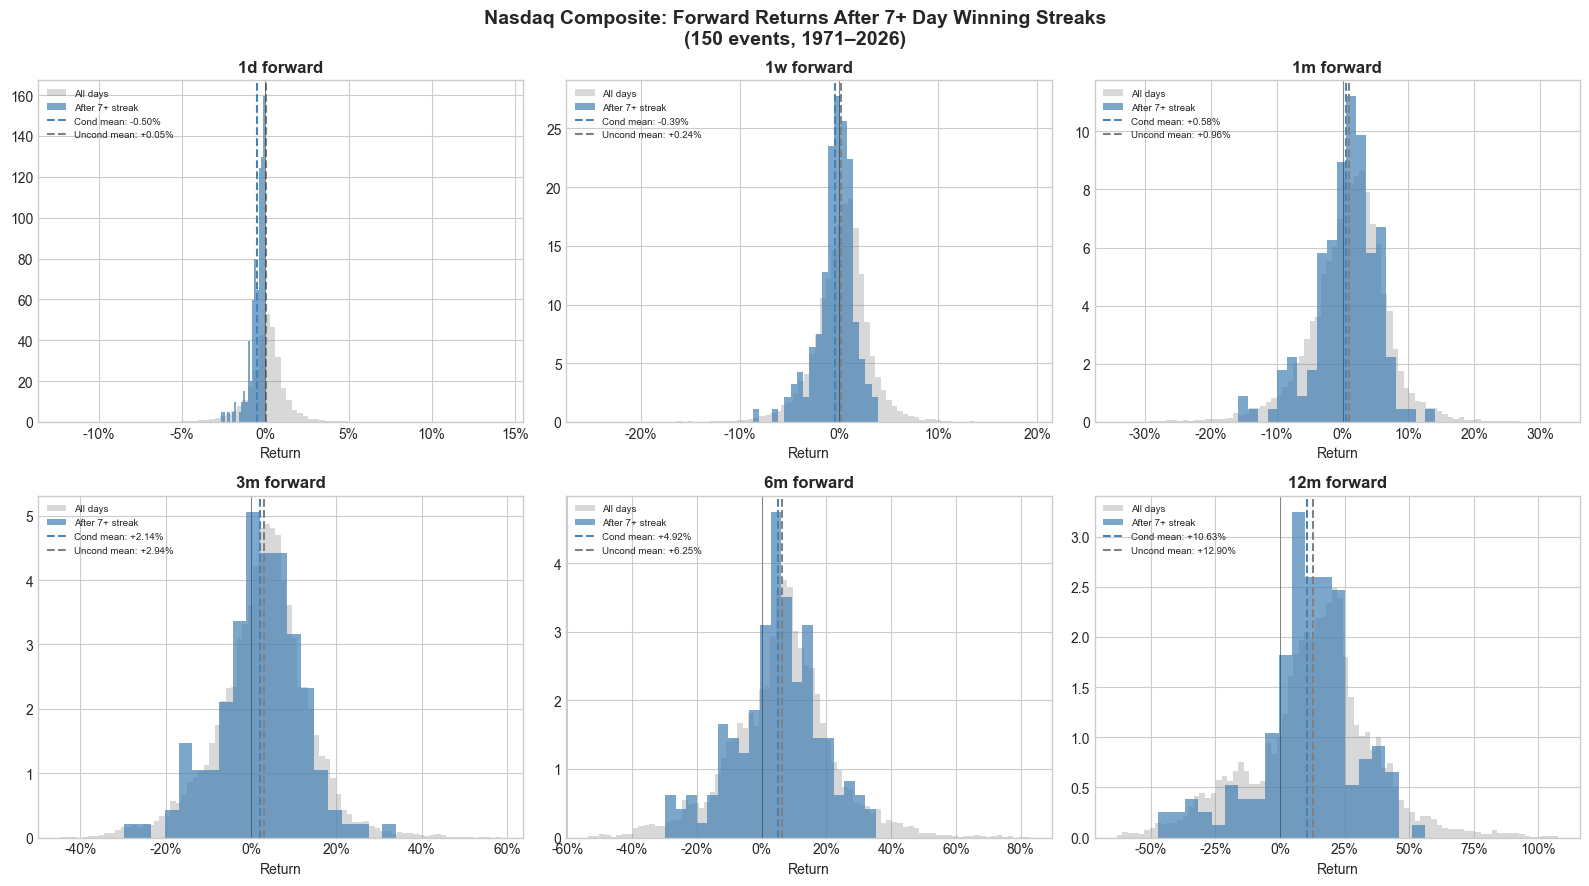

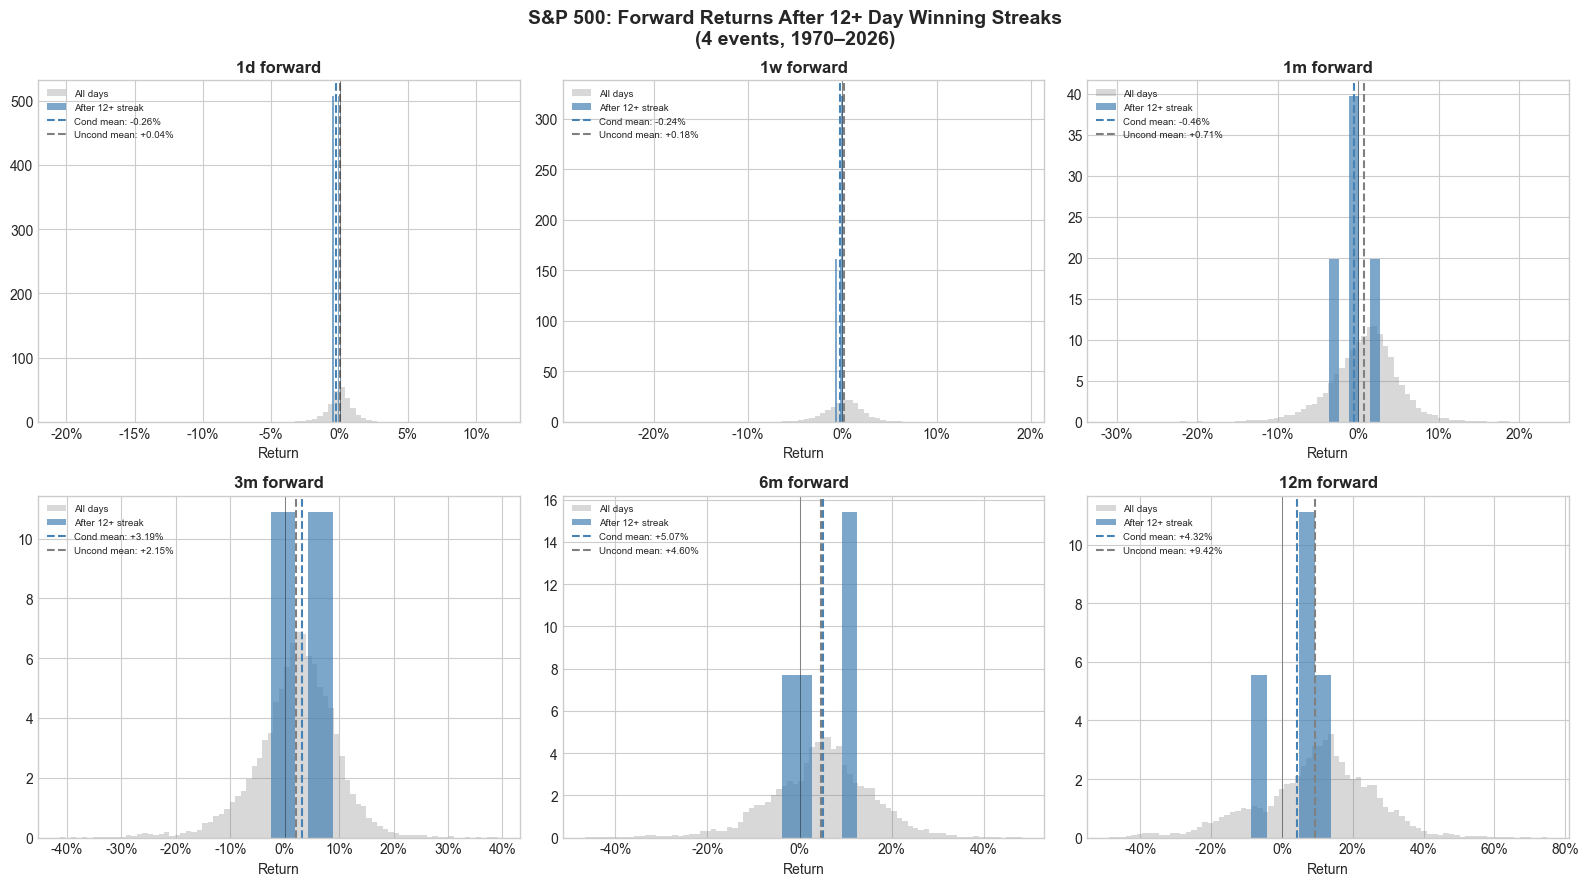

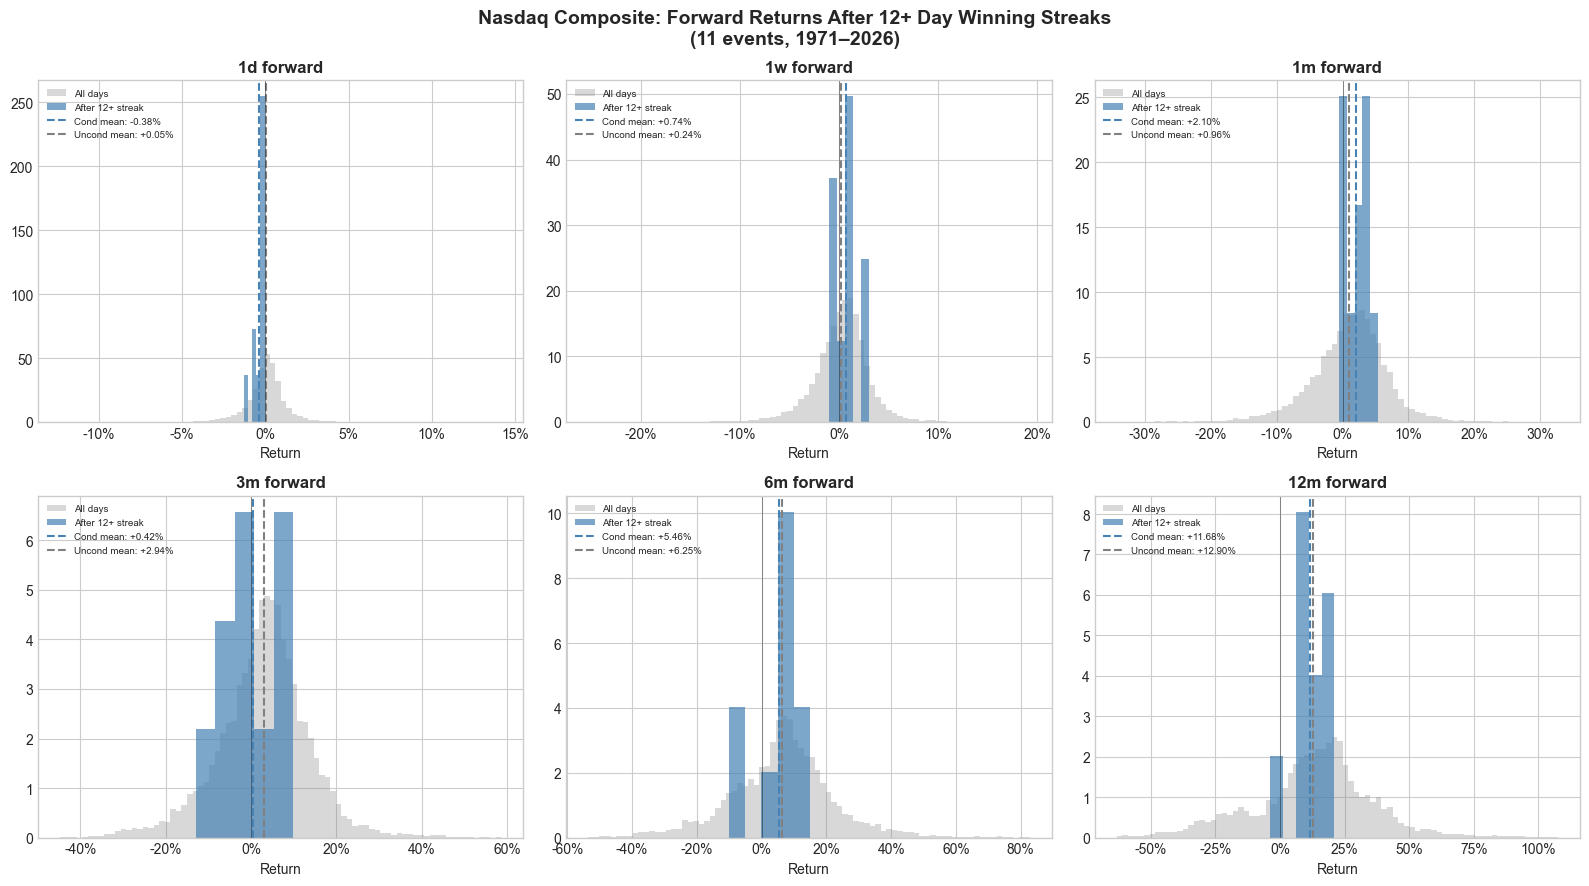

In [8]:
def plot_forward_distributions(price_data: dict, streak_threshold: int, horizons: dict):
    """
    For a given streak threshold, plot conditional vs unconditional
    forward return distributions at each horizon.
    """
    horizon_labels = list(horizons.keys())

    for name, df in price_data.items():
        events = find_streak_events(df, streak_threshold)
        n_events = len(events)

        fig, axes = plt.subplots(2, 3, figsize=(16, 9))
        fig.suptitle(
            f'{name}: Forward Returns After {streak_threshold}+ Day Winning Streaks\n'
            f'({n_events} events, {df.index[0].year}–{df.index[-1].year})',
            fontsize=14, fontweight='bold'
        )

        for idx, label in enumerate(horizon_labels):
            ax = axes.flat[idx]
            col = f'fwd_{label}'

            cond = events[col].dropna()
            uncond = df[col].dropna()

            # Plot unconditional as grey, conditional as colored
            ax.hist(uncond, bins=80, alpha=0.3, color='grey', density=True, label='All days')
            if len(cond) >= 3:
                ax.hist(cond, bins=min(20, max(5, len(cond) // 3)),
                        alpha=0.7, color='steelblue', density=True,
                        label=f'After {streak_threshold}+ streak')
                ax.axvline(cond.mean(), color='steelblue', ls='--', lw=1.5,
                           label=f'Cond mean: {cond.mean():+.2%}')
            ax.axvline(uncond.mean(), color='grey', ls='--', lw=1.5,
                       label=f'Uncond mean: {uncond.mean():+.2%}')
            ax.axvline(0, color='black', ls='-', lw=0.5, alpha=0.5)

            ax.set_title(f'{label} forward', fontweight='bold')
            ax.set_xlabel('Return')
            ax.legend(fontsize=7, loc='upper left')
            ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

        plt.tight_layout()
        plt.show()


# Plot for the most relevant streak lengths
for threshold in [7, 12]:
    plot_forward_distributions(price_data, threshold, FWD_HORIZONS)

## 7. Streak Events Timeline

Show where these streaks occurred on the price chart — useful for eyeballing whether they cluster in specific regimes.

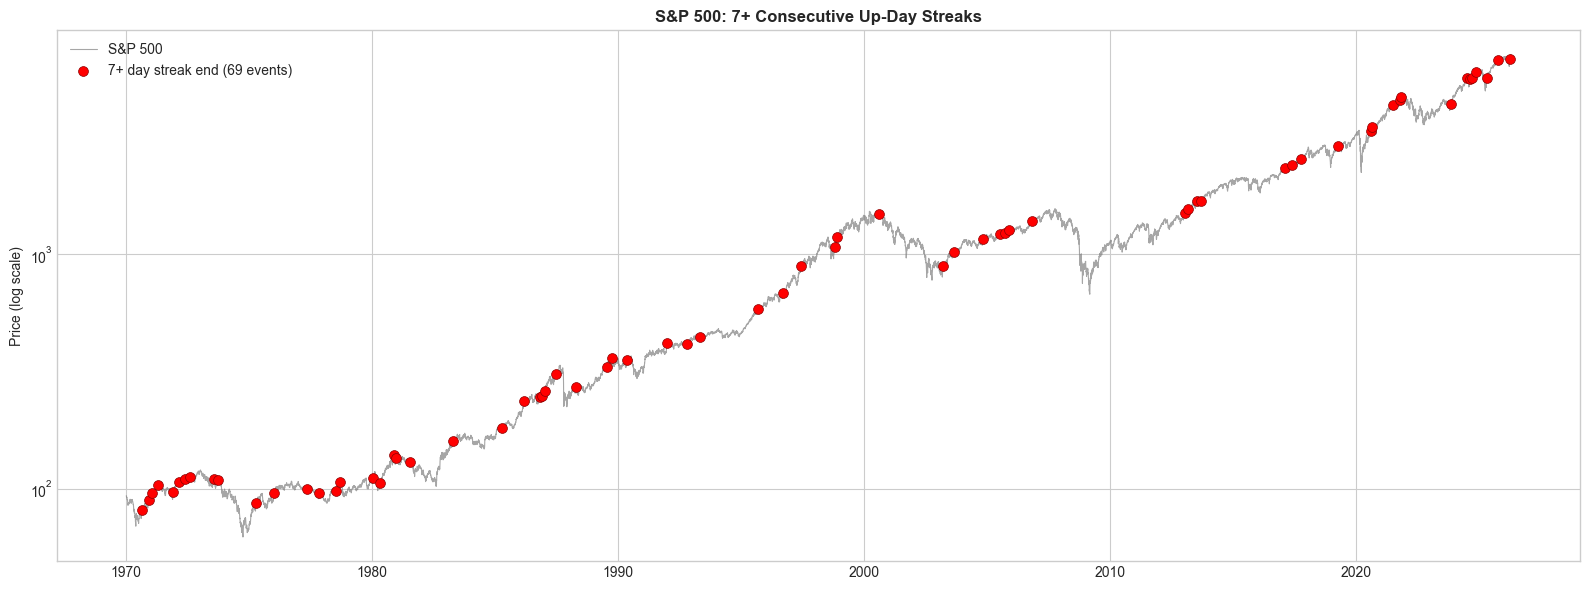


S&P 500 — Streaks of 7+ days:
               close  streak_length  fwd_1d  fwd_1w  fwd_1m   fwd_3m   fwd_6m  fwd_12m
Date                                                                                  
1970-08-26     81.21              9  -0.16%  -0.31%  +0.55%   +2.09%  +19.11%  +22.21%
1970-12-07     89.94             12  -0.52%  -0.16%  +2.68%   +8.87%  +12.40%   +6.56%
1971-01-26     95.59              9  -0.73%  +0.88%  +1.19%   +8.34%   +2.67%   +8.67%
1971-04-15    103.52             14  -0.03%  +0.04%  -0.80%   -2.61%   -3.82%   +5.73%
1971-12-03     97.06              7  -0.57%  +0.65%  +4.75%   +9.80%  +13.01%  +20.05%
1972-03-01    107.35              7  -0.03%  +1.50%  -0.80%   +2.90%   +2.68%   +3.45%
1972-05-26    110.66              8  -0.28%  -1.66%  -2.87%   +1.58%   +5.97%   -2.85%
1972-08-14    112.55             12  -0.44%  -0.74%  -3.63%   +0.71%   +2.27%   -8.74%
1973-07-26    109.85              9  -0.24%  -2.89%  -7.23%   +0.34%  -11.63%  -22.94%
1973-09-27  

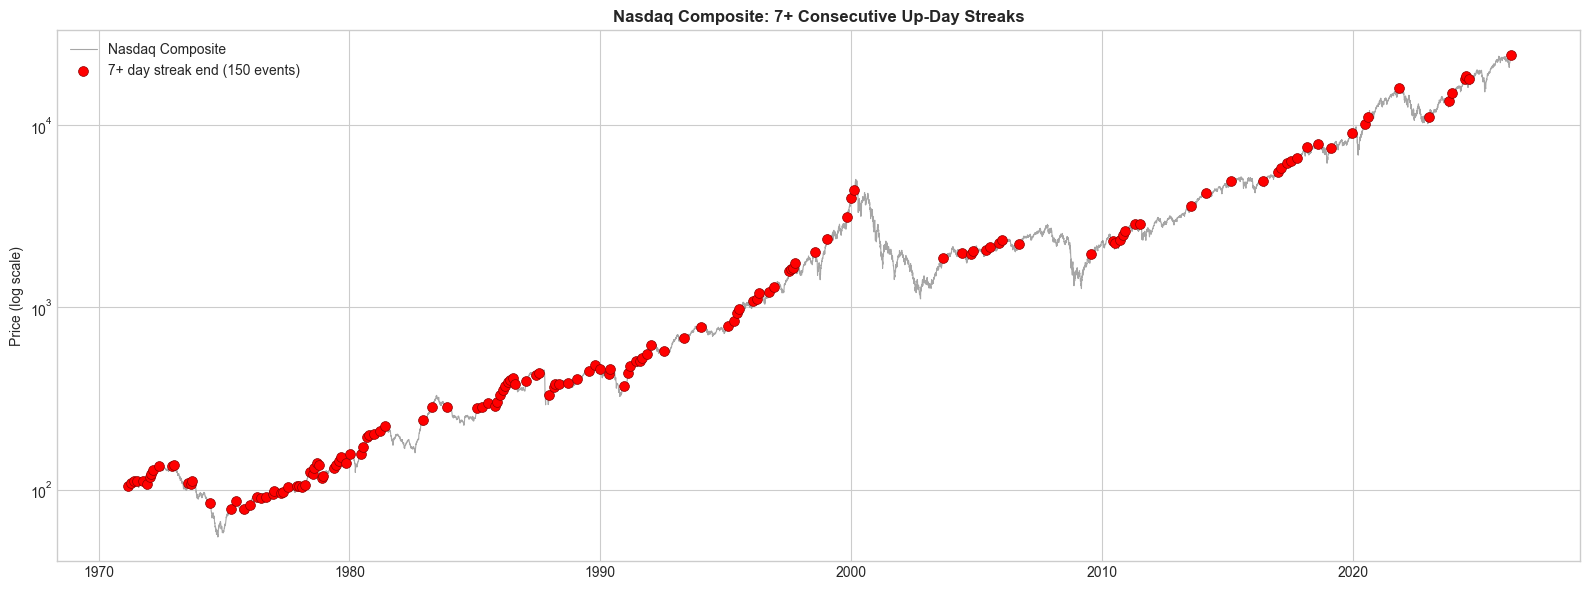


Nasdaq Composite — Streaks of 7+ days:
                close  streak_length  fwd_1d  fwd_1w   fwd_1m   fwd_3m   fwd_6m  fwd_12m
Date                                                                                    
1971-03-09     104.41             11  -0.26%  +1.10%   +3.02%   +5.56%   +5.33%  +21.23%
1971-04-12     108.87             11  -0.02%  +1.18%   +1.18%   +1.05%   +1.94%  +19.41%
1971-06-07     110.76              8  -0.67%  -1.07%   -1.38%   -2.11%   -4.16%  +19.66%
1971-07-12     111.24              9  -0.43%  -1.68%   -7.25%   -1.12%   +4.03%  +18.02%
1971-10-07     110.98              8  -0.22%  -1.00%   -4.88%   +2.41%  +17.14%  +16.51%
1971-12-03     107.26              7  -0.32%  +1.45%   +5.96%  +16.89%  +24.12%  +23.75%
1972-01-12     116.90              7  -0.41%  +0.47%   +4.50%  +12.75%  +11.61%  +16.39%
1972-02-04     121.24              8  -0.08%  +1.34%   +5.48%   +6.68%   +7.48%   +3.93%
1972-03-06     127.88              9  -0.04%  -0.42%   +0.70%   +3.64%

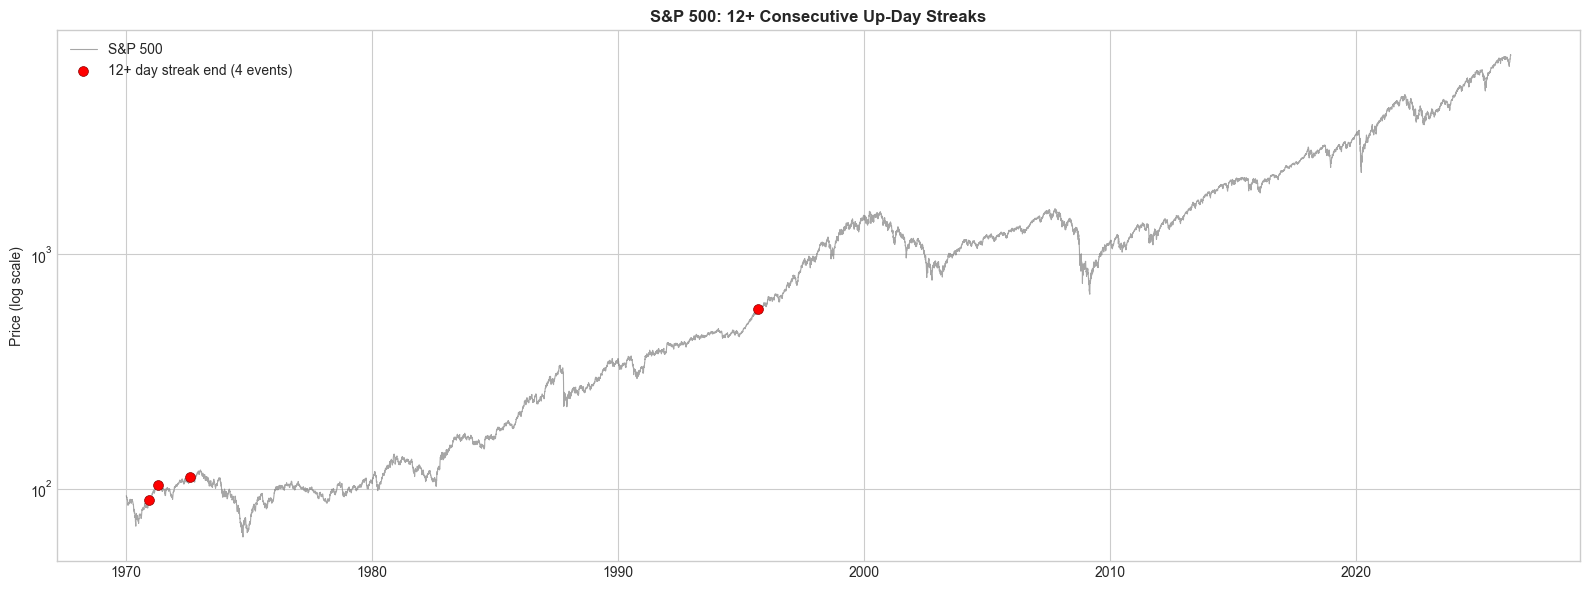


S&P 500 — Streaks of 12+ days:
             close  streak_length  fwd_1d  fwd_1w  fwd_1m  fwd_3m   fwd_6m  fwd_12m
Date                                                                               
1970-12-07   89.94             12  -0.52%  -0.16%  +2.68%  +8.87%  +12.40%   +6.56%
1971-04-15  103.52             14  -0.03%  +0.04%  -0.80%  -2.61%   -3.82%   +5.73%
1972-08-14  112.55             12  -0.44%  -0.74%  -3.63%  +0.71%   +2.27%   -8.74%
1995-09-14  583.61             12  -0.04%  -0.10%  -0.09%  +5.80%   +9.41%  +13.74%



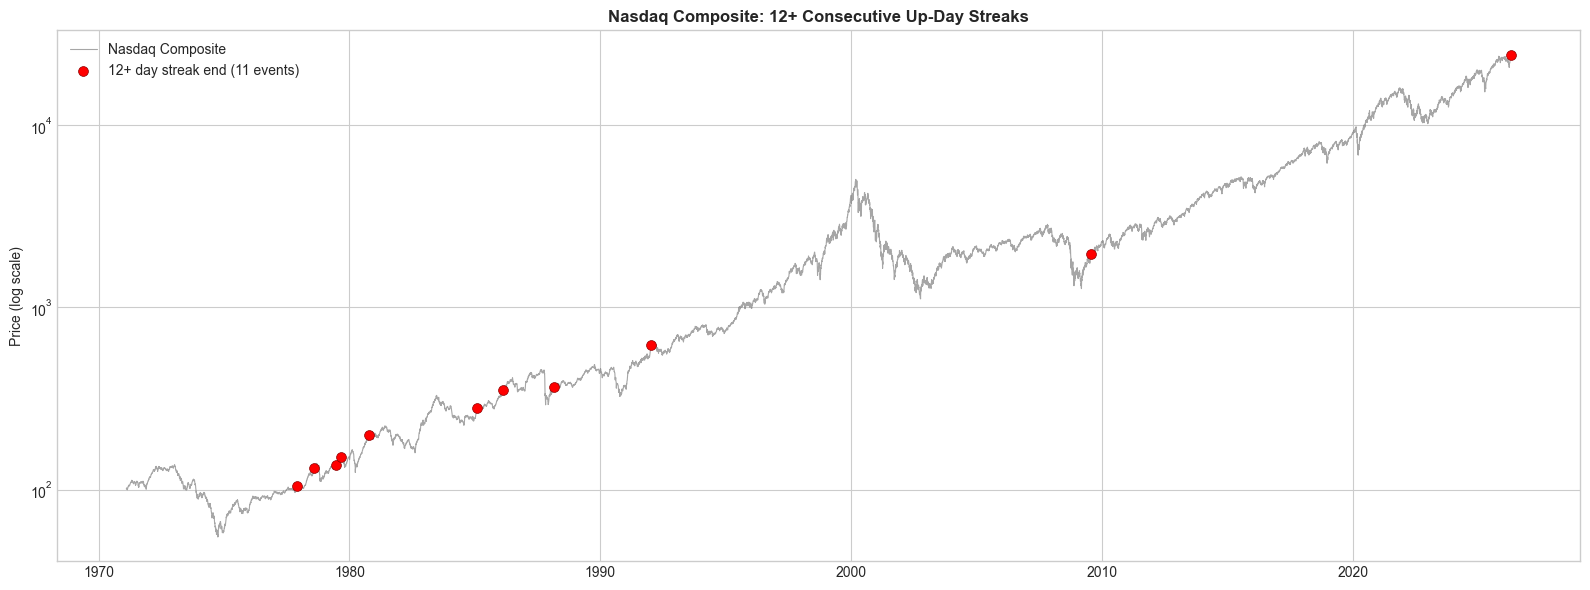


Nasdaq Composite — Streaks of 12+ days:
                close  streak_length  fwd_1d  fwd_1w  fwd_1m   fwd_3m   fwd_6m  fwd_12m
Date                                                                                   
1977-11-25     104.33             15  -0.26%  -0.22%  -0.37%   -2.11%  +14.85%   +9.81%
1978-08-09     131.64             12  -0.05%  +0.86%  +4.14%  -12.92%   -5.57%   +8.18%
1979-06-15     136.25             12  -0.29%  +0.73%  +1.94%   +8.91%   +9.00%  +13.92%
1979-08-31     150.44             19  -1.30%  -1.02%  -0.57%   -5.24%   +5.05%  +21.08%
1980-10-15     199.43             12  -0.74%  -0.77%  +0.41%   -0.69%   +7.80%   -3.77%
1985-01-31     278.70             18  -0.11%  +3.01%  +3.05%   +1.22%   +8.11%  +20.09%
1986-02-18     352.40             12  -0.09%  +0.71%  +5.42%   +9.90%   +7.89%  +16.12%
1988-02-25     363.60             12  -0.06%  +2.31%  +3.30%   +0.66%   +2.72%  +11.77%
1992-01-09     619.80             13  -0.66%  +1.22%  +2.88%   -4.81%  -10.04% 

In [9]:
def plot_streak_timeline(price_data: dict, streak_threshold: int):
    """Plot price with markers on streak events."""
    for name, df in price_data.items():
        events = find_streak_events(df, streak_threshold)

        fig, ax = plt.subplots(figsize=(16, 6))
        ax.semilogy(df.index, df['close'], color='grey', lw=0.8, alpha=0.7, label=name)
        ax.scatter(events.index, events['close'], color='red', s=50, zorder=5,
                   label=f'{streak_threshold}+ day streak end ({len(events)} events)',
                   edgecolors='darkred', linewidths=0.5)

        ax.set_title(f'{name}: {streak_threshold}+ Consecutive Up-Day Streaks', fontweight='bold')
        ax.set_ylabel('Price (log scale)')
        ax.legend()
        plt.tight_layout()
        plt.show()

        # Print the actual events
        print(f'\n{name} — Streaks of {streak_threshold}+ days:')
        display_cols = ['close', 'streak_length']
        fwd_cols = [c for c in events.columns if c.startswith('fwd_')]
        display_df = events[display_cols + fwd_cols].copy()
        for c in fwd_cols:
            display_df[c] = display_df[c].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else '')
        display_df['close'] = display_df['close'].apply(lambda x: f'{x:,.2f}')
        print(display_df.to_string())
        print()


plot_streak_timeline(price_data, 7)
plot_streak_timeline(price_data, 12)

## 8. Cumulative Return After Streak (Average Path)

Overlay the average cumulative return path for the 60 trading days following each streak event vs the unconditional average path from any random day.

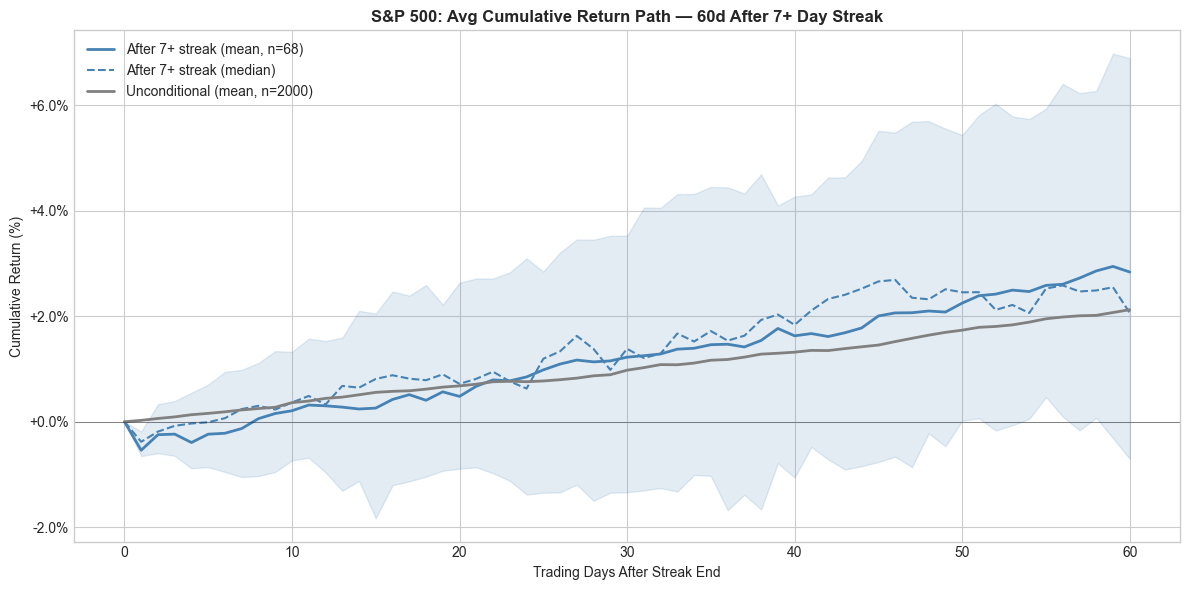

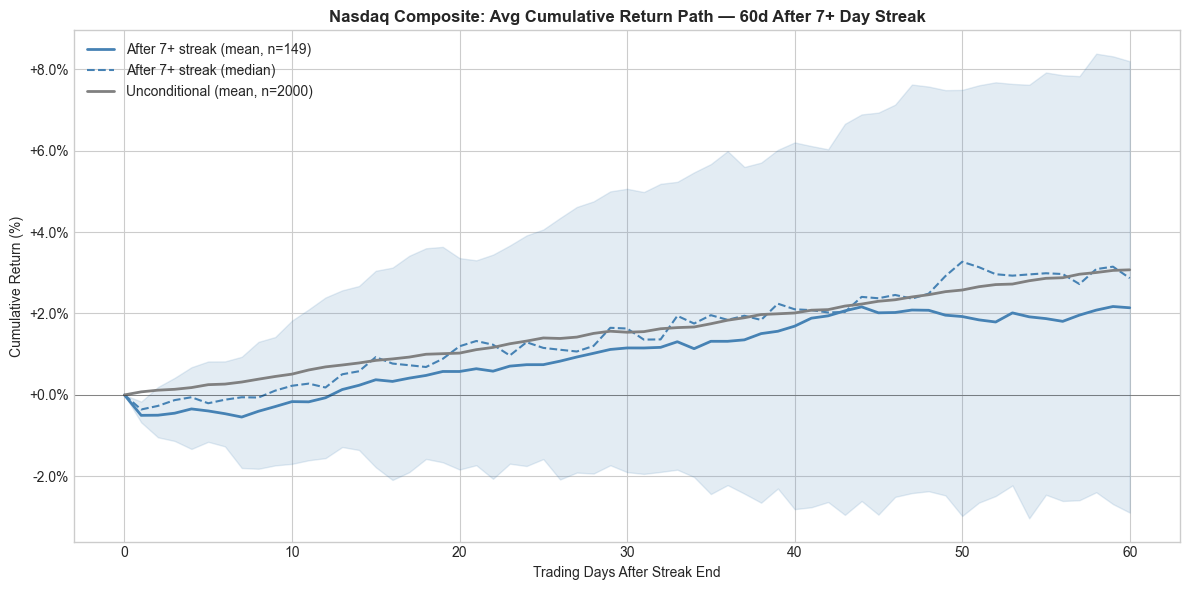

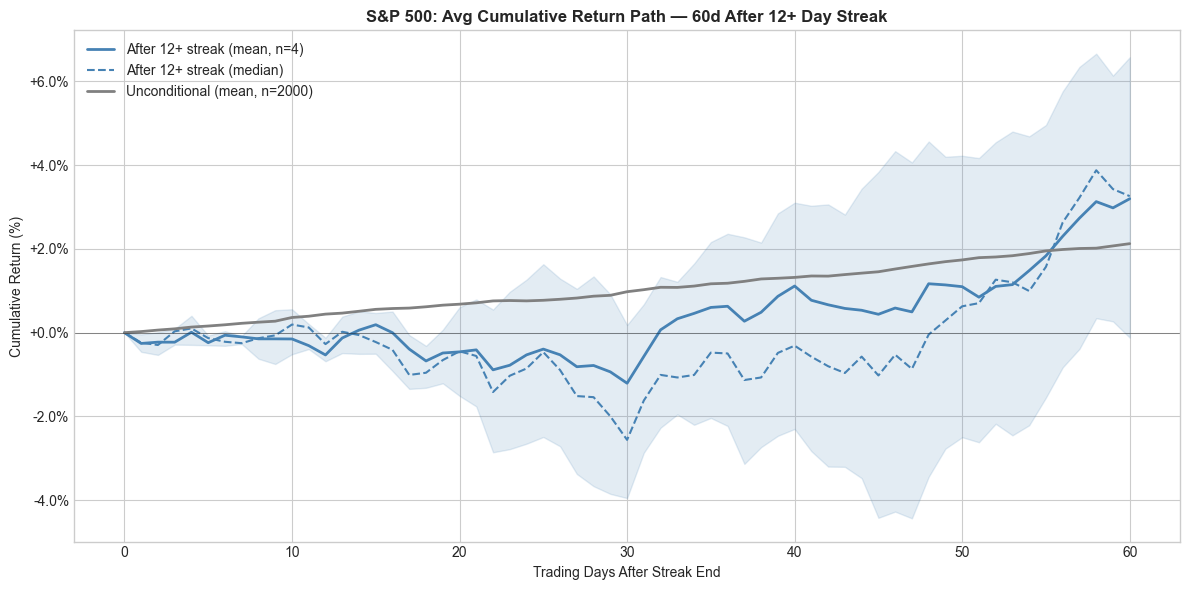

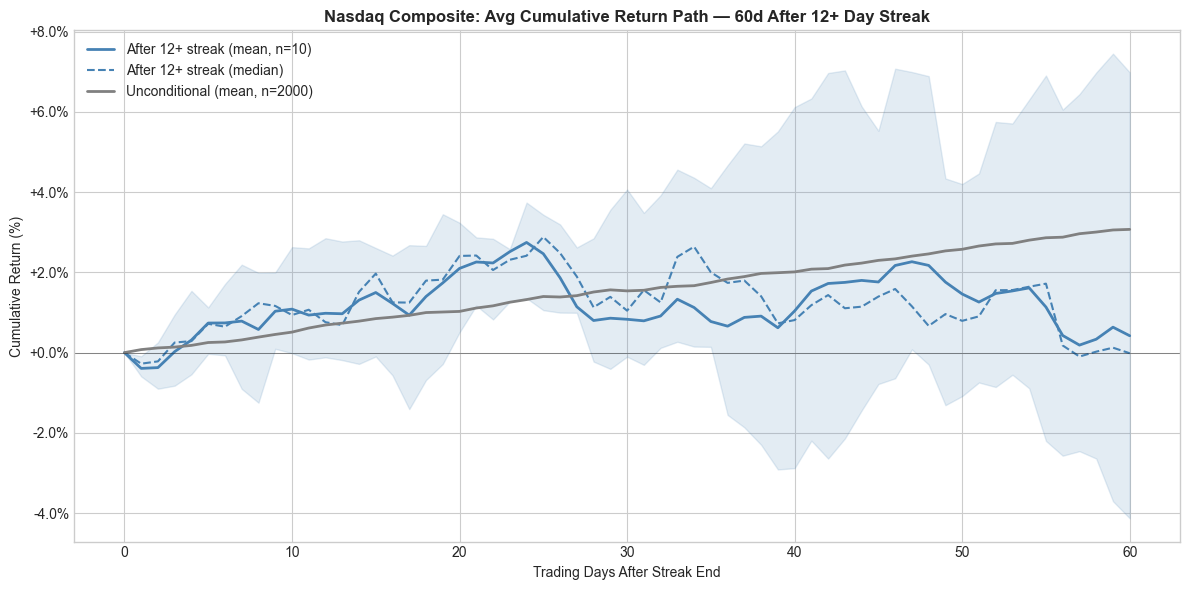

In [10]:
def plot_avg_path(price_data: dict, streak_threshold: int, window: int = 60):
    """
    Compute and plot the average cumulative return path
    for `window` days after each streak event.
    """
    for name, df in price_data.items():
        events = find_streak_events(df, streak_threshold)
        close = df['close'].values
        idx_map = {d: i for i, d in enumerate(df.index)}

        # Collect normalized paths: day 0 = 1.0
        paths = []
        for event_date in events.index:
            i = idx_map[event_date]
            if i + window >= len(close):
                continue
            path = close[i:i + window + 1] / close[i]
            paths.append(path)

        if not paths:
            print(f'Not enough data for {name} with streak {streak_threshold}')
            continue

        paths_arr = np.array(paths)
        mean_path = np.mean(paths_arr, axis=0)
        median_path = np.median(paths_arr, axis=0)
        p25 = np.percentile(paths_arr, 25, axis=0)
        p75 = np.percentile(paths_arr, 75, axis=0)

        # Unconditional: sample N random start points and compute same thing
        np.random.seed(42)
        n_samples = min(2000, len(df) - window)
        rand_starts = np.random.choice(len(df) - window, size=n_samples, replace=False)
        uncond_paths = []
        for s in rand_starts:
            uncond_paths.append(close[s:s + window + 1] / close[s])
        uncond_mean = np.mean(uncond_paths, axis=0)

        # Plot
        days = np.arange(window + 1)
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.fill_between(days, (p25 - 1) * 100, (p75 - 1) * 100, alpha=0.15, color='steelblue')
        ax.plot(days, (mean_path - 1) * 100, color='steelblue', lw=2,
                label=f'After {streak_threshold}+ streak (mean, n={len(paths)})')
        ax.plot(days, (median_path - 1) * 100, color='steelblue', lw=1.5, ls='--',
                label=f'After {streak_threshold}+ streak (median)')
        ax.plot(days, (uncond_mean - 1) * 100, color='grey', lw=2,
                label=f'Unconditional (mean, n={n_samples})')
        ax.axhline(0, color='black', lw=0.5, alpha=0.5)

        ax.set_title(f'{name}: Avg Cumulative Return Path — {window}d After {streak_threshold}+ Day Streak',
                     fontweight='bold')
        ax.set_xlabel('Trading Days After Streak End')
        ax.set_ylabel('Cumulative Return (%)')
        ax.legend()
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.1f}%'))
        plt.tight_layout()
        plt.show()


for threshold in [7, 12]:
    plot_avg_path(price_data, threshold, window=60)

## 9. Streak Magnitude Filter

The Detrick/Carson analysis filters not just by streak *length* but also by streak *total return* (e.g., 7 days with 7%+ cumulative gain). Let's add that dimension.

In [11]:
def find_streak_events_with_magnitude(df: pd.DataFrame, min_streak: int,
                                       min_total_return: float = None) -> pd.DataFrame:
    """
    Like find_streak_events but optionally filters by the total return
    over the streak period.
    
    Parameters
    ----------
    min_total_return : float, optional
        Minimum cumulative return over the streak (e.g., 0.07 for 7%).
    """
    events = find_streak_events(df, min_streak)

    if min_total_return is not None:
        # Compute cumulative return over the streak
        streak_rets = []
        for date in events.index:
            streak_len = int(events.loc[date, 'streak_length'])
            # Get the position in the original df
            pos = df.index.get_loc(date)
            start_pos = pos - streak_len  # day before streak started
            if start_pos < 0:
                streak_rets.append(np.nan)
                continue
            start_price = df.iloc[start_pos]['close']
            end_price = df.loc[date, 'close']
            streak_rets.append(end_price / start_price - 1)

        events['streak_return'] = streak_rets
        events = events[events['streak_return'] >= min_total_return]

    return events


# ── Example: 7-day streak with 7%+ total gain (Detrick criteria) ──
for name, df in price_data.items():
    events = find_streak_events_with_magnitude(df, min_streak=7, min_total_return=0.07)
    print(f'\n{name}: 7+ day streaks with 7%+ total return — {len(events)} events')
    if not events.empty:
        display_cols = ['close', 'streak_length', 'streak_return']
        fwd_cols = [c for c in events.columns if c.startswith('fwd_')]
        display_df = events[display_cols + fwd_cols].copy()
        display_df['streak_return'] = display_df['streak_return'].apply(lambda x: f'{x:+.2%}')
        for c in fwd_cols:
            display_df[c] = display_df[c].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else '')
        display_df['close'] = display_df['close'].apply(lambda x: f'{x:,.2f}')
        print(display_df.to_string())


S&P 500: 7+ day streaks with 7%+ total return — 14 events
               close  streak_length streak_return  fwd_1d  fwd_1w  fwd_1m   fwd_3m   fwd_6m  fwd_12m
Date                                                                                                
1970-08-26     81.21              9        +8.63%  -0.16%  -0.31%  +0.55%   +2.09%  +19.11%  +22.21%
1970-12-07     89.94             12        +8.64%  -0.52%  -0.16%  +2.68%   +8.87%  +12.40%   +6.56%
1971-12-03     97.06              7        +7.65%  -0.57%  +0.65%  +4.75%   +9.80%  +13.01%  +20.05%
1975-04-17     87.25              8        +8.59%  -1.09%  -1.39%  +4.77%   +9.10%   +2.33%  +14.84%
1976-01-12     96.33              8        +7.31%  -0.79%  +2.07%  +3.42%   +7.30%   +8.98%   +9.02%
1980-11-18    139.70              8        +8.37%  -0.46%  -0.26%  -4.87%   -9.11%   -5.45%  -12.91%
1987-01-12    260.30              7        +7.49%  -0.13%  +3.47%  +6.86%  +13.98%  +18.47%   +0.30%
1990-05-14    354.75            

## 10. Key Takeaways

Run the cells above and look for:

1. **Is the conditional mean meaningfully different from unconditional?** Check the p-values — with small N (especially at 12+ streaks) you'll likely lack statistical power, which is itself informative.

2. **Win rate vs baseline:** If after a 7-day streak the 3m forward win rate is 85% vs 65% unconditional, that's practically interesting even if not statistically significant at p<0.05.

3. **Regime clustering:** The timeline chart will show you whether streaks cluster in specific macro environments. If every 12-day streak happened during a QE cycle, that's a confounding variable worth noting.

4. **Magnitude matters:** The Detrick filter (7 days + 7% total return) likely captures a *different* signal than just 7 consecutive green days with tiny returns. The magnitude-filtered results may be more interesting.

5. **Practical limitations:**
   - Small sample sizes at higher streak thresholds (12+ days might have <10 events)
   - Survivorship/selection bias in a single index
   - No risk-adjustment (sharp rally could precede higher vol)
   
### Extensions to consider:
- Add volatility context (was the streak during low or high VIX?)
- Test on other assets (crude, gold, rates) — different microstructures
- Look at drawdown profiles post-streak, not just point-to-point returns
- Cross-asset: does an equity streak predict commodity or rates moves?